# Advertising Mean-Field Control

## Simplex MF-REINFORCE Only

This notebook is a fixed-simplex-only version of the advertising numerical experiment. It uses exact population recursion for validation throughout, with either exact or particle-estimated population flow during training.

1. **Nominal-budget exact flow.** Simplex uses `(B, n_aux) = (200, 10)`.
2. **Full-budget exact flow.** Simplex uses `(B, n_aux) = (5425, 775)`, matching the simplex budget from the equal-simulator-budget comparison for `T = 5`.
3. **Full-budget estimated flow.** The same simplex budget is used with a particle flow estimate using `flow_particles = 200`.

Validation reports exact return, finite-horizon DP regret, policy error, flow error, advertising expenditure, and customer share.

## Imports

In [1]:
from __future__ import annotations

import copy
import math
import random
import sys
import time
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from mfc.algorithms import SimplexPerturbedMFREINFORCE
from mfc.environments import AdvertisingConfig, AdvertisingMFC, AdvertisingPolicy


/home/adonis/Internship/MFC_RL/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Runtime And General Helpers

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
torch.set_default_dtype(DTYPE)


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)


set_seed(0)
print(f"device: {device}")


def format_runtime(seconds: Optional[float]) -> str:
    if seconds is None:
        return "not set"
    seconds = float(seconds)
    hours, remainder = divmod(int(seconds), 3600)
    minutes, secs = divmod(remainder, 60)
    if hours:
        return f"{hours:d}h {minutes:02d}m {secs:02d}s"
    if minutes:
        return f"{minutes:d}m {secs:02d}s"
    return f"{seconds:.1f}s"


def std_ddof(n: int) -> int:
    return 1 if n > 1 else 0


def safe_name(name: object) -> str:
    text = str(name)
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in text).strip("_") or "advertising"


def tensor_float(value, default: float = float("nan")) -> float:
    if value is None:
        return default
    if isinstance(value, torch.Tensor):
        if value.numel() != 1:
            return default
        return float(value.detach().cpu().item())
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def aligned_validation_history(runs):
    min_len = min(len(run["history"]["validation_value"]) for run in runs)
    episodes = np.asarray(runs[0]["history"]["episode"][:min_len], dtype=float)
    values = np.asarray([run["history"]["validation_value"][:min_len] for run in runs], dtype=float)
    return episodes, values


def aligned_history_metric(runs, key: str):
    lengths = [len(run["history"].get(key, [])) for run in runs]
    if not lengths or min(lengths) == 0:
        return np.asarray([]), np.asarray([])
    min_len = min(lengths)
    episodes = np.asarray(runs[0]["history"]["episode"][:min_len], dtype=float)
    values = np.asarray([run["history"][key][:min_len] for run in runs], dtype=float)
    return episodes, values


device: cuda


## Policy, Run Plan, And Flow Helpers

In [3]:
def customer_law(p: torch.Tensor, config: AdvertisingConfig) -> torch.Tensor:
    p = torch.as_tensor(p, dtype=config.dtype, device=config.device)
    return torch.stack([1.0 - p, p], dim=-1)


def sample_advertising_initial_laws(config: AdvertisingConfig, count: int) -> torch.Tensor:
    return AdvertisingMFC(config).sample_initial_laws(count).detach().cpu()


def clone_state_dict(policy: AdvertisingPolicy) -> Dict[str, torch.Tensor]:
    return {key: value.detach().cpu().clone() for key, value in policy.state_dict().items()}


def prepare_paired_run_plans(
    config: AdvertisingConfig,
    seed_base: int = 71_000,
    training_runs: Optional[int] = None,
) -> List[Dict[str, object]]:
    n_runs = config.training_runs if training_runs is None else int(training_runs)
    plans: List[Dict[str, object]] = []
    for run_idx in range(n_runs):
        seed = seed_base + run_idx
        set_seed(seed)
        policy = AdvertisingPolicy(config)
        plans.append(
            {
                "run_idx": run_idx,
                "seed": seed,
                "initial_control": {"state_dict": clone_state_dict(policy)},
                "initial_laws": sample_advertising_initial_laws(config, config.n_train),
            }
        )
    return plans


def load_policy(
    config: AdvertisingConfig,
    payload: Dict[str, object],
    trainable: bool = True,
) -> AdvertisingPolicy:
    policy = AdvertisingPolicy(config)
    state = {
        key: value.to(dtype=config.dtype, device=config.device).detach().clone()
        for key, value in payload["state_dict"].items()
    }
    policy.load_state_dict(state)
    policy.train(trainable)
    for parameter in policy.parameters():
        parameter.requires_grad_(trainable)
    return policy


def payload_from_record(record: Dict[str, object]) -> Dict[str, object]:
    return {"state_dict": {key: value.detach().cpu().clone() for key, value in record["policy_state_dict"].items()}}


def parameter_vector(policy: AdvertisingPolicy) -> torch.Tensor:
    return torch.nn.utils.parameters_to_vector(policy.parameters()).detach()


def assign_flat_ascent_gradient(policy: AdvertisingPolicy, grad_hat: torch.Tensor) -> None:
    grad_flat = grad_hat.detach().reshape(-1)
    offset = 0
    for parameter in policy.parameters():
        count = parameter.numel()
        parameter.grad = -grad_flat[offset : offset + count].reshape_as(parameter).clone()
        offset += count
    if offset != grad_flat.numel():
        raise ValueError(f"Gradient length {grad_flat.numel()} does not match policy parameter length {offset}.")


@torch.no_grad()
def exact_population_flow_batch(
    env: AdvertisingMFC,
    policy: AdvertisingPolicy,
    mu0_batch: torch.Tensor,
    horizon: int,
) -> torch.Tensor:
    flow = [mu0_batch]
    for t in range(horizon):
        flow.append(env.next_law(policy, t, flow[-1]))
    return torch.stack(flow, dim=1)


def training_population_flow(
    env: AdvertisingMFC,
    algorithm,
    policy: AdvertisingPolicy,
    mu0: torch.Tensor,
    horizon: int,
    flow_mode: str,
    flow_particles: int,
) -> torch.Tensor:
    if flow_mode == "exact":
        with torch.no_grad():
            return env.exact_population_flow(policy, mu0, horizon).detach()
    if flow_mode == "particle":
        return algorithm.estimate_population_flow(policy, mu0, flow_particles, horizon=horizon).detach()
    raise ValueError(f"Unknown flow_mode={flow_mode!r}.")


## Metrics, Costs, And Perturbation Calibration

In [4]:
def total_variation_distance(p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
    return 0.5 * (p - q).abs().sum(dim=-1)


def interpolate_on_grid(x: torch.Tensor, grid: torch.Tensor, values: torch.Tensor) -> torch.Tensor:
    x = x.to(dtype=grid.dtype, device=grid.device).clamp(float(grid[0].item()), float(grid[-1].item()))
    right = torch.searchsorted(grid, x).clamp(1, grid.numel() - 1)
    left = right - 1
    left_grid = grid[left]
    right_grid = grid[right]
    weight = (x - left_grid) / (right_grid - left_grid).clamp_min(torch.finfo(grid.dtype).eps)
    return values[left] * (1.0 - weight) + values[right] * weight


def oracle_flow_batch(
    env: AdvertisingMFC,
    oracle: Dict[str, torch.Tensor],
    mu0_batch: torch.Tensor,
    horizon: int,
) -> torch.Tensor:
    p = mu0_batch[..., env.config.CUSTOMER]
    flow = [mu0_batch]
    for t in range(horizon):
        q = interpolate_on_grid(p, oracle["p_grid"], oracle["policy"][t])
        increment = q * torch.minimum(torch.full_like(p, env.config.kappa_ad), 1.0 - p)
        p = (p + increment).clamp(0.0, 1.0)
        flow.append(torch.stack([1.0 - p, p], dim=-1))
    return torch.stack(flow, dim=1)


def reference_metrics(
    env: AdvertisingMFC,
    policy: AdvertisingPolicy,
    validation_laws: torch.Tensor,
    oracle: Dict[str, torch.Tensor],
    horizon: int,
) -> Dict[str, object]:
    validation_laws = validation_laws.to(dtype=env.config.dtype, device=env.config.device)
    was_training = policy.training
    policy.eval()
    try:
        with torch.no_grad():
            flow = exact_population_flow_batch(env, policy, validation_laws, horizon).detach()
            p_flow = flow[..., env.config.CUSTOMER]
            values = torch.zeros(validation_laws.shape[0], dtype=env.config.dtype, device=env.config.device)
            ad_costs = torch.zeros_like(values)
            ad_rates = []
            discount = 1.0
            for t in range(horizon):
                q_t = env.advertising_rate(policy, t, flow[:, t])
                ad_rates.append(q_t)
                values = values + discount * (p_flow[:, t] - env.config.c_ad * q_t)
                ad_costs = ad_costs + discount * env.config.c_ad * q_t
                discount *= env.config.gamma
            ad_rates_t = torch.stack(ad_rates, dim=1) if ad_rates else torch.zeros(validation_laws.shape[0], 0, dtype=env.config.dtype, device=env.config.device)

            p0 = validation_laws[:, env.config.CUSTOMER]
            optimal_values = interpolate_on_grid(p0, oracle["p_grid"], oracle["values"][0])
            regret = optimal_values - values
            optimal_flow = oracle_flow_batch(env, oracle, validation_laws, horizon)
            flow_error = (flow[:, 1:, env.config.CUSTOMER] - optimal_flow[:, 1:, env.config.CUSTOMER]).abs().mean()

            grid_laws = validation_laws
            p_grid = grid_laws[:, env.config.CUSTOMER]
            policy_errors = []
            reference_errors = []
            reference_q = env.infinite_horizon_reference_policy(p_grid)
            for t in range(horizon):
                learned_q = policy.advertising_probability(t, grid_laws)
                optimal_q = interpolate_on_grid(p_grid, oracle["p_grid"], oracle["policy"][t])
                policy_errors.append((learned_q - optimal_q).abs().mean())
                reference_errors.append((learned_q - reference_q).abs().mean())
            policy_error = torch.stack(policy_errors).mean() if policy_errors else torch.zeros((), dtype=env.config.dtype, device=env.config.device)
            reference_policy_error = torch.stack(reference_errors).mean() if reference_errors else torch.zeros((), dtype=env.config.dtype, device=env.config.device)
    finally:
        policy.train(was_training)

    metrics: Dict[str, object] = {
        "value": float(values.mean().item()),
        "value_std": float(values.std(unbiased=validation_laws.shape[0] > 1).item()),
        "regret": float(regret.mean().item()),
        "policy_error": float(policy_error.item()),
        "flow_error": float(flow_error.item()),
        "reference_policy_error": float(reference_policy_error.item()),
        "advertising_cost": float(ad_costs.mean().item()),
        "mean_advertising_rate": float(ad_rates_t.mean().item()) if ad_rates_t.numel() else float("nan"),
        "final_customer_share": float(p_flow[:, -1].mean().item()),
        "initial_customer_share": float(p_flow[:, 0].mean().item()),
        "flow": flow.mean(dim=0).detach().cpu(),
        "optimal_flow": optimal_flow.mean(dim=0).detach().cpu(),
        "advertising_rate": ad_rates_t.mean(dim=0).detach().cpu(),
        "values_by_initial_law": values.detach().cpu(),
        "regret_by_initial_law": regret.detach().cpu(),
    }
    return metrics


def record_numeric_history(history: Dict[str, List[float]], metrics: Dict[str, object]) -> None:
    for key, value in metrics.items():
        if isinstance(value, (int, float, np.integer, np.floating)):
            history.setdefault(key, []).append(float(value))


def simulator_transitions_per_update(
    algorithm_name: str,
    horizon: int,
    B: int,
    n_aux_or_inner: int,
    flow_mode: str = "exact",
    flow_particles: int = 0,
) -> int:
    normalized = algorithm_name.lower().replace("-", "").replace("_", "").replace(" ", "")
    if normalized in {"simplex", "fixedsimplex"}:
        core = (int(B) + int(n_aux_or_inner)) * int(horizon)
    elif normalized == "logits":
        core = int(B) * int(horizon) + int(B) * int(n_aux_or_inner) * int(horizon) * (int(horizon) + 1) // 2
    else:
        raise ValueError(f"Unknown algorithm_name={algorithm_name!r}.")
    flow_cost = 0 if flow_mode == "exact" else int(flow_particles) * int(horizon)
    return int(math.ceil(core + flow_cost))


def simplex_budget_matching_logit(
    horizon: int,
    logit_B: int = 200,
    logit_n: int = 10,
    simplex_aux_fraction: float = 0.125,
) -> Dict[str, Dict[str, int]]:
    simplex_total_paths = int(logit_B) + int(logit_B) * int(logit_n) * (int(horizon) + 1) // 2
    simplex_n = int(round(simplex_total_paths * simplex_aux_fraction))
    simplex_B = int(simplex_total_paths - simplex_n)
    return {
        "Simplex": {"B": simplex_B, "n": simplex_n},
        "Logits": {"B": int(logit_B), "n": int(logit_n)},
    }


def simulator_cost_table(
    horizon: int,
    flow_mode: str,
    budgets: Dict[str, Dict[str, int]],
    flow_particles: int = 0,
) -> pd.DataFrame:
    budget = budgets["Simplex"]
    cost = simulator_transitions_per_update(
        "Simplex",
        horizon,
        budget["B"],
        budget["n"],
        flow_mode=flow_mode,
        flow_particles=flow_particles,
    )
    return pd.DataFrame(
        [
            {
                "algorithm": "Simplex",
                "B": budget["B"],
                "n": budget["n"],
                "horizon": horizon,
                "flow_mode": flow_mode,
                "flow_particles": flow_particles if flow_mode == "particle" else 0,
                "simulator_transitions_per_update": cost,
                "ratio_vs_simplex": 1.0,
            }
        ]
    ).set_index("algorithm")


def collect_reference_laws(config: AdvertisingConfig, count: int) -> torch.Tensor:
    return sample_advertising_initial_laws(config, count).to(dtype=config.dtype, device=config.device)


def calibrate_perturbation_radii(
    config: AdvertisingConfig,
    reference_laws: torch.Tensor,
    simplex_lambdas: Sequence[float],
    logit_epsilons: Sequence[float],
    num_samples: int = 20_000,
) -> pd.DataFrame:
    reference_laws = reference_laws.to(dtype=config.dtype, device=config.device)
    if reference_laws.shape[0] > num_samples:
        indices = torch.randperm(reference_laws.shape[0], device=config.device)[:num_samples]
        reference_laws = reference_laws[indices]
    rows = []
    sample_count = reference_laws.shape[0]

    u = config.q_sigma * torch.randn(sample_count, config.n_states - 1, dtype=config.dtype, device=config.device)
    simplex_logits = torch.cat([u, torch.zeros(sample_count, 1, dtype=config.dtype, device=config.device)], dim=-1)
    q_simplex = torch.softmax(simplex_logits, dim=-1).clamp_min(config.q_clip)
    q_simplex = q_simplex / q_simplex.sum(dim=-1, keepdim=True)
    for value in simplex_lambdas:
        perturbed = (1.0 - float(value)) * reference_laws + float(value) * q_simplex
        tv = total_variation_distance(perturbed, reference_laws).detach().cpu().numpy()
        rows.append(
            {
                "algorithm": "Simplex",
                "parameter": float(value),
                "tv_mean": float(tv.mean()),
                "tv_std": float(tv.std(ddof=std_ddof(len(tv)))),
                "tv_q10": float(np.quantile(tv, 0.10)),
                "tv_q90": float(np.quantile(tv, 0.90)),
            }
        )

    base_logits = torch.log(reference_laws.clamp_min(config.q_clip))
    lambdas = torch.randn(sample_count, config.n_states, dtype=config.dtype, device=config.device)
    for value in logit_epsilons:
        perturbed = torch.softmax(base_logits + float(value) * lambdas, dim=-1)
        tv = total_variation_distance(perturbed, reference_laws).detach().cpu().numpy()
        rows.append(
            {
                "algorithm": "Logits",
                "parameter": float(value),
                "tv_mean": float(tv.mean()),
                "tv_std": float(tv.std(ddof=std_ddof(len(tv)))),
                "tv_q10": float(np.quantile(tv, 0.10)),
                "tv_q90": float(np.quantile(tv, 0.90)),
            }
        )
    return pd.DataFrame(rows)


## Training Runners

In [5]:
ALGORITHM_NAME = "Simplex"


def train_advertising_simplex(
    config: AdvertisingConfig,
    simplex_lambdas: Sequence[float],
    budget: Dict[str, int],
    run_plans: List[Dict[str, object]],
    validation_laws: torch.Tensor,
    oracle: Dict[str, torch.Tensor],
    flow_mode: str,
    flow_particles: int,
    train_horizon: int,
    validation_horizon: int,
    label: str,
    show_progress: bool = True,
    early_stopping_patience: Optional[int] = None,
    early_stopping_min_delta: float = 0.0,
    max_runtime_seconds: Optional[float] = None,
) -> Dict[float, List[Dict[str, object]]]:
    B = int(budget["B"])
    n_aux = int(budget["n"])
    results: Dict[float, List[Dict[str, object]]] = {}

    for simplex_lambda in simplex_lambdas:
        parameter_key = float(simplex_lambda)
        results[parameter_key] = []
        for run_idx, plan in enumerate(run_plans):
            set_seed(int(plan["seed"]))
            env = AdvertisingMFC(config)
            policy = load_policy(config, plan["initial_control"], trainable=True)
            optimizer = torch.optim.Adam(policy.parameters(), lr=config.lr)
            algorithm = SimplexPerturbedMFREINFORCE(env)
            history: Dict[str, List[float]] = {
                "episode": [],
                "validation_value": [],
                "train_return_mean": [],
                "grad_norm": [],
                "lambda": [],
                "cumulative_simulator_transitions": [],
                "elapsed_seconds": [],
            }
            cumulative_transitions = 0
            run_start = time.perf_counter()
            stop_reason = "completed"
            episodes_completed = 0
            best_validation = -float("inf")
            best_episode = None
            best_state_dict = None
            checks_since_best = 0

            iterator = range(config.n_train)
            if show_progress:
                iterator = tqdm(iterator, desc=f"{label} Simplex lambda={parameter_key:g} run={run_idx}")

            for episode in iterator:
                if max_runtime_seconds is not None and time.perf_counter() - run_start >= max_runtime_seconds:
                    stop_reason = f"max_runtime_{format_runtime(max_runtime_seconds)}"
                    break

                mu0 = plan["initial_laws"][episode].to(dtype=config.dtype, device=config.device)
                mu_flow = training_population_flow(env, algorithm, policy, mu0, train_horizon, flow_mode, flow_particles)
                optimizer.zero_grad(set_to_none=True)
                grad_hat, diag = algorithm.complete_gradient_estimate(
                    policy,
                    mu_flow,
                    parameter_key,
                    B,
                    n_aux,
                    eta=parameter_key,
                    baseline="batch_mean",
                )
                assign_flat_ascent_gradient(policy, grad_hat)
                optimizer.step()

                step_cost = simulator_transitions_per_update(
                    "Simplex",
                    train_horizon,
                    B,
                    n_aux,
                    flow_mode=flow_mode,
                    flow_particles=flow_particles,
                )
                cumulative_transitions += step_cost
                episodes_completed = episode + 1

                if episode % config.validate_every == 0 or episode == config.n_train - 1:
                    metrics = reference_metrics(env, policy, validation_laws, oracle, validation_horizon)
                    history["episode"].append(episode)
                    history["validation_value"].append(metrics["value"])
                    history["train_return_mean"].append(tensor_float(diag.get("mean_return")))
                    history["grad_norm"].append(tensor_float(diag.get("grad_norm")))
                    history["lambda"].append(parameter_key)
                    history["cumulative_simulator_transitions"].append(float(cumulative_transitions))
                    history["elapsed_seconds"].append(time.perf_counter() - run_start)
                    record_numeric_history(history, metrics)

                    if metrics["value"] > best_validation + early_stopping_min_delta:
                        best_validation = metrics["value"]
                        best_episode = episode
                        best_state_dict = clone_state_dict(policy)
                        checks_since_best = 0
                    else:
                        checks_since_best += 1

                    if show_progress:
                        iterator.set_postfix(
                            value=f"{metrics['value']:.4g}",
                            regret=f"{metrics['regret']:.3g}",
                            grad=f"{tensor_float(diag.get('grad_norm')):.3g}",
                        )

                    if early_stopping_patience is not None and checks_since_best >= early_stopping_patience:
                        stop_reason = f"early_stopping_{early_stopping_patience}"
                        break

            if best_state_dict is not None:
                policy.load_state_dict({key: value.to(config.device) for key, value in best_state_dict.items()})
            final_metrics = reference_metrics(env, policy, validation_laws, oracle, validation_horizon)
            runtime_seconds = time.perf_counter() - run_start
            record = {
                "algorithm": "Simplex",
                "parameter": parameter_key,
                "run_idx": run_idx,
                "seed": int(plan["seed"]),
                "history": history,
                "policy_state_dict": clone_state_dict(policy),
                "reference_metrics": final_metrics,
                "final_value": final_metrics["value"],
                "final_regret": final_metrics["regret"],
                "final_policy_error": final_metrics["policy_error"],
                "final_flow_error": final_metrics["flow_error"],
                "best_validation_value": best_validation,
                "best_episode": best_episode,
                "episodes_completed": episodes_completed,
                "stop_reason": stop_reason,
                "runtime_seconds": runtime_seconds,
                "simulator_transitions_per_update": simulator_transitions_per_update(
                    "Simplex",
                    train_horizon,
                    B,
                    n_aux,
                    flow_mode=flow_mode,
                    flow_particles=flow_particles,
                ),
                "total_simulator_transitions": cumulative_transitions,
                "main_trajectories": B,
                "auxiliary_trajectories": n_aux,
                "flow_mode": flow_mode,
                "flow_particles": flow_particles if flow_mode == "particle" else 0,
            }
            results[parameter_key].append(record)
            print(
                f"{label} Simplex lambda={parameter_key:g} run={run_idx} "
                f"value={final_metrics['value']:.6g} regret={final_metrics['regret']:.6g} "
                f"transitions={cumulative_transitions} runtime={format_runtime(runtime_seconds)}"
            )
    return results


def run_advertising_simplex_scenario(
    name: str,
    config: AdvertisingConfig,
    simplex_lambdas: Sequence[float],
    budgets: Dict[str, Dict[str, int]],
    run_plans: List[Dict[str, object]],
    validation_laws: torch.Tensor,
    oracle: Dict[str, torch.Tensor],
    flow_mode: str,
    flow_particles: int = 0,
    train_horizon: Optional[int] = None,
    validation_horizon: Optional[int] = None,
    show_progress: bool = True,
    early_stopping_patience: Optional[int] = None,
    max_runtime_seconds: Optional[float] = None,
) -> Dict[str, object]:
    if train_horizon is None:
        train_horizon = config.T
    if validation_horizon is None:
        validation_horizon = config.T
    costs = simulator_cost_table(train_horizon, flow_mode, budgets, flow_particles=flow_particles)
    display(costs.round(4))
    simplex_results = train_advertising_simplex(
        config,
        simplex_lambdas,
        budgets["Simplex"],
        run_plans,
        validation_laws,
        oracle,
        flow_mode,
        flow_particles,
        train_horizon,
        validation_horizon,
        label=name,
        show_progress=show_progress,
        early_stopping_patience=early_stopping_patience,
        max_runtime_seconds=max_runtime_seconds,
    )
    return {
        "name": name,
        "flow_mode": flow_mode,
        "flow_particles": flow_particles if flow_mode == "particle" else 0,
        "train_horizon": train_horizon,
        "validation_horizon": validation_horizon,
        "budgets": copy.deepcopy(budgets),
        "costs": costs,
        "results": {"Simplex": simplex_results},
    }


## Reporting And Plotting

In [6]:
def metric_from_run(run: Dict[str, object], key: str) -> float:
    if key in run.get("reference_metrics", {}):
        return float(run["reference_metrics"][key])
    return float(run[key])


def summarize_metric_rows(result_groups, metric_keys: Sequence[str]) -> pd.DataFrame:
    rows = []
    for algorithm_name, result_group in result_groups.items():
        for perturbation, runs in result_group.items():
            row = {"algorithm": algorithm_name, "parameter": float(perturbation), "runs": len(runs)}
            ddof = std_ddof(len(runs))
            for key in metric_keys:
                values = np.asarray([metric_from_run(run, key) for run in runs], dtype=float)
                row[f"{key}_mean"] = float(values.mean())
                row[f"{key}_std"] = float(values.std(ddof=ddof))
            for key in [
                "runtime_seconds",
                "episodes_completed",
                "main_trajectories",
                "auxiliary_trajectories",
                "simulator_transitions_per_update",
                "total_simulator_transitions",
                "best_validation_value",
            ]:
                if key in runs[0]:
                    row[f"{key}_mean"] = float(np.mean([run[key] for run in runs]))
            rows.append(row)
    return pd.DataFrame(rows).set_index(["algorithm", "parameter"]).sort_index()


def interpolate_metric(x: np.ndarray, y: np.ndarray, target_x: np.ndarray) -> np.ndarray:
    order = np.argsort(x)
    x = np.asarray(x, dtype=float)[order]
    y = np.asarray(y, dtype=float)[order]
    unique_x, inverse = np.unique(x, return_inverse=True)
    if len(unique_x) != len(x):
        y_accum = np.zeros_like(unique_x, dtype=float)
        counts = np.zeros_like(unique_x, dtype=float)
        for idx, value in zip(inverse, y):
            y_accum[idx] += value
            counts[idx] += 1
        x = unique_x
        y = y_accum / counts
    return np.interp(target_x, x, y, left=np.nan, right=np.nan)


def radius_summary(result_groups, calibration: pd.DataFrame, metric_key: str = "value") -> pd.DataFrame:
    rows = []
    for algorithm_name, result_group in result_groups.items():
        for perturbation, runs in result_group.items():
            radius_row = calibration[
                (calibration["algorithm"] == algorithm_name)
                & np.isclose(calibration["parameter"], float(perturbation))
            ]
            values = np.asarray([metric_from_run(run, metric_key) for run in runs], dtype=float)
            rows.append(
                {
                    "algorithm": algorithm_name,
                    "parameter": float(perturbation),
                    "radius": float(radius_row.iloc[0]["tv_mean"]) if not radius_row.empty else float("nan"),
                    f"{metric_key}_mean": values.mean(),
                    f"{metric_key}_std": values.std(ddof=std_ddof(len(values))),
                }
            )
    return pd.DataFrame(rows).set_index(["algorithm", "parameter"]).sort_index()


LINE_STYLES = {"Simplex": "-"}


def plot_validation_groups(result_groups, title: str):
    fig, ax = plt.subplots(figsize=(10.5, 5.2))
    keys = [(algorithm_name, parameter) for algorithm_name, group in result_groups.items() for parameter in group]
    cmap = plt.get_cmap("tab20", max(len(keys), 1))
    colors = {key: cmap(idx) for idx, key in enumerate(keys)}
    for algorithm_name, result_group in result_groups.items():
        for perturbation, runs in result_group.items():
            episodes, values = aligned_validation_history(runs)
            mean = values.mean(axis=0)
            std = values.std(axis=0, ddof=std_ddof(len(runs)))
            color = colors[(algorithm_name, perturbation)]
            ax.plot(
                episodes,
                mean,
                linestyle=LINE_STYLES.get(algorithm_name, "-"),
                color=color,
                label=f"{algorithm_name}, p={perturbation:g}",
            )
            ax.fill_between(episodes, mean - std, mean + std, color=color, alpha=0.12)
    ax.set_title(title)
    ax.set_xlabel("Training iteration")
    ax.set_ylabel("Exact validation value (mean +/- std. dev.)")
    ax.grid(alpha=0.25)
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    plt.show()


def best_parameter_for_group(result_group: Dict[float, List[Dict[str, object]]]) -> float:
    rows = []
    for parameter, runs in result_group.items():
        values = np.asarray([run["final_value"] for run in runs], dtype=float)
        regrets = np.asarray([run["final_regret"] for run in runs], dtype=float)
        rows.append(
            {
                "parameter": float(parameter),
                "value_mean": values.mean(),
                "value_std": values.std(ddof=std_ddof(len(values))),
                "regret_mean": regrets.mean(),
            }
        )
    return float(pd.DataFrame(rows).sort_values(["value_mean", "value_std", "parameter"], ascending=[False, True, True]).iloc[0]["parameter"])


def plot_best_population_flows(result_groups, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
    for algorithm_name, result_group in result_groups.items():
        best_parameter = best_parameter_for_group(result_group)
        runs = result_group[best_parameter]
        flows = np.asarray([run["reference_metrics"]["flow"].numpy() for run in runs], dtype=float)
        ad_rates = np.asarray([run["reference_metrics"]["advertising_rate"].numpy() for run in runs], dtype=float)
        optimal = np.asarray([run["reference_metrics"]["optimal_flow"].numpy() for run in runs], dtype=float).mean(axis=0)
        mean_flow = flows.mean(axis=0)
        mean_ad = ad_rates.mean(axis=0)
        times = np.arange(mean_flow.shape[0])
        axes[0].plot(times, mean_flow[:, 1], linestyle=LINE_STYLES.get(algorithm_name, "-"), label=f"{algorithm_name}, p={best_parameter:g}")
        axes[1].plot(np.arange(mean_ad.shape[0]), mean_ad, linestyle=LINE_STYLES.get(algorithm_name, "-"), label=f"{algorithm_name}, p={best_parameter:g}")
    axes[0].plot(np.arange(optimal.shape[0]), optimal[:, 1], color="black", linestyle=":", label="DP oracle")
    axes[0].set_title("Mean customer share")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("p_t")
    axes[1].set_title("Mean advertising probability")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("q_t")
    for ax in axes:
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def scenario_summary_table(scenario: Dict[str, object], experiment: str, horizon: Optional[int] = None) -> pd.DataFrame:
    metric_keys = ["value", "regret", "policy_error", "flow_error", "advertising_cost", "final_customer_share"]
    table = summarize_metric_rows(scenario["results"], metric_keys).reset_index()
    table.insert(0, "experiment", experiment)
    table.insert(1, "flow_mode", scenario["flow_mode"])
    table.insert(2, "T", scenario["train_horizon"] if horizon is None else horizon)
    table.insert(3, "flow_particles", int(scenario["flow_particles"]))
    leading_columns = ["experiment", "flow_mode", "T", "flow_particles", "algorithm", "parameter"]
    return table[leading_columns + [column for column in table.columns if column not in leading_columns]]


def show_advertising_results(scenario: Dict[str, object], calibration: pd.DataFrame):
    result_groups = scenario["results"]
    metrics = ["value", "regret", "policy_error", "flow_error", "advertising_cost", "final_customer_share"]
    display(summarize_metric_rows(result_groups, metrics).round(6))
    print("Calibrated TV radii")
    display(radius_summary(result_groups, calibration, metric_key="value").round(6))
    plot_validation_groups(result_groups, f"{scenario['name']}: exact validation value")
    plot_best_population_flows(result_groups, f"{scenario['name']}: best population flows")


## Exact-Gradient Diagnostics

In [7]:
def exact_gradient(
    env: AdvertisingMFC,
    policy: AdvertisingPolicy,
    mu0: torch.Tensor,
    horizon: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    for parameter in policy.parameters():
        parameter.requires_grad_(True)
    value = env.exact_value(policy, mu0, horizon)
    grads = torch.autograd.grad(value, tuple(policy.parameters()), allow_unused=False)
    flat_grad = torch.cat([grad.detach().reshape(-1) for grad in grads])
    return value.detach(), flat_grad


def cosine_similarity_flat(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x.flatten() @ y.flatten() / denom).item())


def simplex_gradient_diagnostic_summary(
    config: AdvertisingConfig,
    payload: Dict[str, object],
    simplex_lambda: float,
    budget: Dict[str, int],
    mu0: torch.Tensor,
    horizon: int,
    flow_mode: str,
    flow_particles: int,
    repetitions: int,
    label: str,
    show_progress: bool = True,
) -> Dict[str, object]:
    env = AdvertisingMFC(config)
    policy = load_policy(config, payload, trainable=True)
    mu0 = mu0.to(dtype=config.dtype, device=config.device)
    B = int(budget["B"])
    n_aux = int(budget["n"])
    _, oracle_grad = exact_gradient(env, policy, mu0, horizon)
    per_estimate_transitions = simulator_transitions_per_update(
        "Simplex",
        horizon,
        B,
        n_aux,
        flow_mode=flow_mode,
        flow_particles=flow_particles,
    )

    samples = []
    iterator = range(repetitions)
    if show_progress:
        iterator = tqdm(iterator, desc=f"{label} Simplex lambda={simplex_lambda:g}", leave=False)
    algorithm = SimplexPerturbedMFREINFORCE(env)

    for _ in iterator:
        mu_flow = training_population_flow(env, algorithm, policy, mu0, horizon, flow_mode, flow_particles)
        grad_hat, _ = algorithm.complete_gradient_estimate(
            policy,
            mu_flow,
            float(simplex_lambda),
            B,
            n_aux,
            eta=float(simplex_lambda),
            baseline="batch_mean",
        )
        samples.append(grad_hat.detach().reshape(-1))

    samples_t = torch.stack(samples)
    mean_grad = samples_t.mean(dim=0)
    bias = mean_grad - oracle_grad
    covariance_trace = float(samples_t.var(dim=0, unbiased=repetitions > 1).sum().item()) if repetitions > 1 else 0.0
    mse = ((samples_t - oracle_grad.unsqueeze(0)).square().sum(dim=1)).mean()
    return {
        "label": label,
        "algorithm": "Simplex",
        "flow_mode": flow_mode,
        "flow_particles": flow_particles if flow_mode == "particle" else 0,
        "parameter": float(simplex_lambda),
        "repetitions": repetitions,
        "B": B,
        "n_aux_or_inner": n_aux,
        "oracle_grad_norm": float(torch.linalg.norm(oracle_grad).item()),
        "mean_grad_norm": float(torch.linalg.norm(mean_grad).item()),
        "bias_norm": float(torch.linalg.norm(bias).item()),
        "covariance_trace": covariance_trace,
        "mse": float(mse.item()),
        "cosine_to_oracle": cosine_similarity_flat(mean_grad, oracle_grad),
        "simulator_transitions_per_estimate": int(per_estimate_transitions),
        "simulator_transitions": int(per_estimate_transitions * repetitions),
    }


def run_advertising_simplex_diagnostics(
    scenario: Dict[str, object],
    config: AdvertisingConfig,
    simplex_lambdas: Sequence[float],
    run_plans: List[Dict[str, object]],
    repetitions: int = 8,
    show_progress: bool = True,
) -> pd.DataFrame:
    results = scenario["results"]
    best_simplex = best_parameter_for_group(results["Simplex"])
    controls = [
        ("initial", run_plans[0]["initial_control"]),
        (f"simplex_final_lambda_{best_simplex:g}", payload_from_record(results["Simplex"][best_simplex][0])),
    ]
    rows = []
    mu0 = customer_law(torch.tensor(0.5, dtype=config.dtype, device=config.device), config)
    for label, payload in controls:
        for simplex_lambda in simplex_lambdas:
            rows.append(
                simplex_gradient_diagnostic_summary(
                    config,
                    payload,
                    simplex_lambda,
                    scenario["budgets"]["Simplex"],
                    mu0,
                    scenario["train_horizon"],
                    scenario["flow_mode"],
                    scenario["flow_particles"],
                    repetitions,
                    label,
                    show_progress=show_progress,
                )
            )
    return pd.DataFrame(rows)


## Common Experiment Setup

In [8]:
config = AdvertisingConfig(
    device=device,
    dtype=DTYPE,
    T=5,
    hidden_units=32,
    N=500,
    n=10,
    n_train=10_000,
    lr=1e-4,
    training_runs=2,
    validate_every=50,
)
train_horizon = config.T
validation_horizon = config.T

env_for_setup = AdvertisingMFC(config)
validation_laws = env_for_setup.validation_initial_laws(grid_size=101)
advertising_oracle = env_for_setup.finite_horizon_dp_oracle(grid_size=1001, action_grid_size=1001)

simplex_lambdas = [0.05, 0.1, 0.2, 0.4]
nominal_simplex_budgets = {"Simplex": {"B": 200, "n": 10}}
full_simplex_budgets = {"Simplex": simplex_budget_matching_logit(train_horizon, logit_B=200, logit_n=10)["Simplex"]}
assert full_simplex_budgets == {"Simplex": {"B": 5425, "n": 775}}
particle_flow_particles = 200

early_stopping_patience = None
max_runtime_seconds = None
diagnostic_repetitions = 8
perturbation_calibration_samples = 20_000
reference_law_count = 20_000

advertising_run_plans = prepare_paired_run_plans(config, seed_base=73_000)
advertising_reference_laws = collect_reference_laws(config, reference_law_count)
advertising_calibration = calibrate_perturbation_radii(
    config,
    advertising_reference_laws,
    simplex_lambdas,
    [],
    num_samples=perturbation_calibration_samples,
)
advertising_calibration = advertising_calibration[advertising_calibration["algorithm"] == "Simplex"].reset_index(drop=True)

exact_nominal_costs = simulator_cost_table(train_horizon, "exact", nominal_simplex_budgets)
exact_full_costs = simulator_cost_table(train_horizon, "exact", full_simplex_budgets)
particle_full_costs = simulator_cost_table(
    train_horizon,
    "particle",
    full_simplex_budgets,
    flow_particles=particle_flow_particles,
)

display(advertising_calibration.round(4))
print("Exact flow, nominal simplex budget")
display(exact_nominal_costs.round(4))
print("Exact flow, full simplex budget")
display(exact_full_costs.round(4))
print("Estimated particle flow, full simplex budget")
display(particle_full_costs.round(4))


,algorithm,parameter,tv_mean,tv_std,tv_q10,tv_q90
0,Simplex,0.05,0.0136,0.0095,0.0022,0.0276
1,Simplex,0.10,0.0273,0.0191,0.0044,0.0552
2,Simplex,0.20,0.0546,0.0382,0.0088,0.1103
3,Simplex,0.40,0.1092,0.0764,0.0176,0.2206


Exact flow, nominal simplex budget


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,200,10,5,exact,0,1050,1.0


Exact flow, full simplex budget


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,5425,775,5,exact,0,31000,1.0


Estimated particle flow, full simplex budget


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,5425,775,5,particle,200,32000,1.0


## Experiment 1: Exact Flow, Nominal Simplex Budget

Simplex uses `(B, n_aux) = (200, 10)`.

In [9]:
exact_nominal_budget = run_advertising_simplex_scenario(
    "simplex_nominal_exact",
    config,
    simplex_lambdas,
    nominal_simplex_budgets,
    advertising_run_plans,
    validation_laws,
    advertising_oracle,
    flow_mode="exact",
    train_horizon=train_horizon,
    validation_horizon=validation_horizon,
    show_progress=True,
    early_stopping_patience=early_stopping_patience,
    max_runtime_seconds=max_runtime_seconds,
)


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,200,10,5,exact,0,1050,1.0


simplex_nominal_exact Simplex lambda=0.05 run=0: 100%|██████████| 10000/10000 [06:29<00:00, 25.68it/s, grad=0.0365, regret=0.042, value=0.9668]  


simplex_nominal_exact Simplex lambda=0.05 run=0 value=0.967233 regret=0.0415506 transitions=10500000 runtime=6m 29s


simplex_nominal_exact Simplex lambda=0.05 run=1: 100%|██████████| 10000/10000 [07:29<00:00, 22.25it/s, grad=1.39, regret=0.0428, value=0.966]    


simplex_nominal_exact Simplex lambda=0.05 run=1 value=0.967113 regret=0.0416712 transitions=10500000 runtime=7m 29s


...

simplex_nominal_exact Simplex lambda=0.2 run=1 value=0.968619 regret=0.0401648 transitions=10500000 runtime=8m 58s


simplex_nominal_exact Simplex lambda=0.4 run=0: 100%|██████████| 10000/10000 [08:05<00:00, 20.59it/s, grad=0.417, regret=0.0375, value=0.9713] 


simplex_nominal_exact Simplex lambda=0.4 run=0 value=0.971561 regret=0.0372232 transitions=10500000 runtime=8m 05s


simplex_nominal_exact Simplex lambda=0.4 run=1: 100%|██████████| 10000/10000 [09:11<00:00, 18.14it/s, grad=0.0757, regret=0.0367, value=0.972]

simplex_nominal_exact Simplex lambda=0.4 run=1 value=0.972113 regret=0.0366706 transitions=10500000 runtime=9m 11s


,label,algorithm,flow_mode,flow_particles,parameter,repetitions,B,n_aux_or_inner,oracle_grad_norm,mean_grad_norm,bias_norm,covariance_trace,mse,cosine_to_oracle,simulator_transitions_per_estimate,simulator_transitions
0,initial,Simplex,exact,0,0.05,8,200,10,0.007614,19.119247,19.113970,7.424943e+03,6.862170e+03,0.693227,1050,8400
1,initial,Simplex,exact,0,0.10,8,200,10,0.007614,65.651062,65.646873,2.062131e+04,2.235315e+04,0.549657,1050,8400
2,initial,Simplex,exact,0,0.20,8,200,10,0.007614,4.730872,4.726801,4.054850e+02,3.771420e+02,0.535259,1050,8400
3,initial,Simplex,exact,0,0.40,8,200,10,0.007614,0.095742,0.095461,2.897350e-01,2.626310e-01,0.076639,1050,8400
4,simplex_final_lambda_0.4,Simplex,exact,0,0.05,8,200,10,0.020914,19341.634766,19341.656250,2.645927e+09,2.689286e+09,-0.994151,1050,8400
5,simplex_final_lambda_0.4,Simplex,exact,0,0.10,8,200,10,0.020914,505.621124,505.600342,1.535730e+06,1.599396e+06,0.992988,1050,8400
6,simplex_final_lambda_0.4,Simplex,exact,0,0.20,8,200,10,0.020914,2.704191,2.683316,5.145207e+01,5.222074e+01,0.998167,1050,8400
7,simplex_final_lambda_0.4,Simplex,exact,0,0.40,8,200,10,0.020914,0.087933,0.098428,3.300040e-01,2.984420e-01,-0.412862,1050,8400


runs  value_mean  value_std  regret_mean  regret_std  \
algorithm parameter                                                         
Simplex   0.05          2    0.967173   0.000085     0.041611    0.000085   
          0.10          2    0.967495   0.000633     0.041289    0.000633   
          0.20          2    0.968352   0.000378     0.040432    0.000378   
          0.40          2    0.971837   0.000391     0.036947    0.000391   

                     policy_error_mean  policy_error_std  flow_error_mean  \
algorithm parameter                                                         
Simplex   0.05                0.471852          0.009585         0.091078   
          0.10                0.469692          0.004186         0.094322   
          0.20                0.464394          0.008851         0.096124   
          0.40                0.416435          0.000197         0.151504   

                     flow_error_std  advertising_cost_mean  \
algorithm parameter                                          
Simplex   0.05             0.005145               0.139019   
          0.10             0.001149               0.133919   
          0.20             0.004167               0.130097   
          0.40             0.007656               0.082498   

                     advertising_cost_std  final_customer_share_mean  \
algorithm parameter                                                    
Simplex   0.05                   0.007090                   0.861819   
          0.10                   0.002933                   0.853469   
          0.20                   0.004699                   0.846071   
          0.40                   0.007030                   0.735331   

                     final_customer_share_std  runtime_seconds_mean  \
algorithm parameter                                                   
Simplex   0.05                       0.016883            419.386206   
          0.10                       0.000257            477.981555   
          0.20                       0.014537            558.252278   
          0.40                       0.012355            518.519346   

                     episodes_completed_mean  main_trajectories_mean  \
algorithm parameter                                                    
Simplex   0.05                       10000.0                   200.0   
          0.10                       10000.0                   200.0   
          0.20                       10000.0                   200.0   
          0.40                       10000.0                   200.0   

                     auxiliary_trajectories_mean  \
algorithm parameter                                
Simplex   0.05                              10.0   
          0.10                              10.0   
          0.20                              10.0   
          0.40                              10.0   

                     simulator_transitions_per_update_mean  \
algorithm parameter                                          
Simplex   0.05                                      1050.0   
          0.10                                      1050.0   
          0.20                                      1050.0   
          0.40                                      1050.0   

                     total_simulator_transitions_mean  \
algorithm parameter                                     
Simplex   0.05                             10500000.0   
          0.10                             10500000.0   
          0.20                             10500000.0   
          0.40                             10500000.0   

                     best_validation_value_mean  
algorithm parameter                              
Simplex   0.05                         0.967173  
          0.10                         0.967495  
          0.20                         0.968352  
          0.40                         0.971837

Calibrated TV radii


radius  value_mean  value_std
algorithm parameter                                 
Simplex   0.05       0.013649    0.967173   0.000085
          0.10       0.027297    0.967495   0.000633
          0.20       0.054594    0.968352   0.000378
          0.40       0.109188    0.971837   0.000391

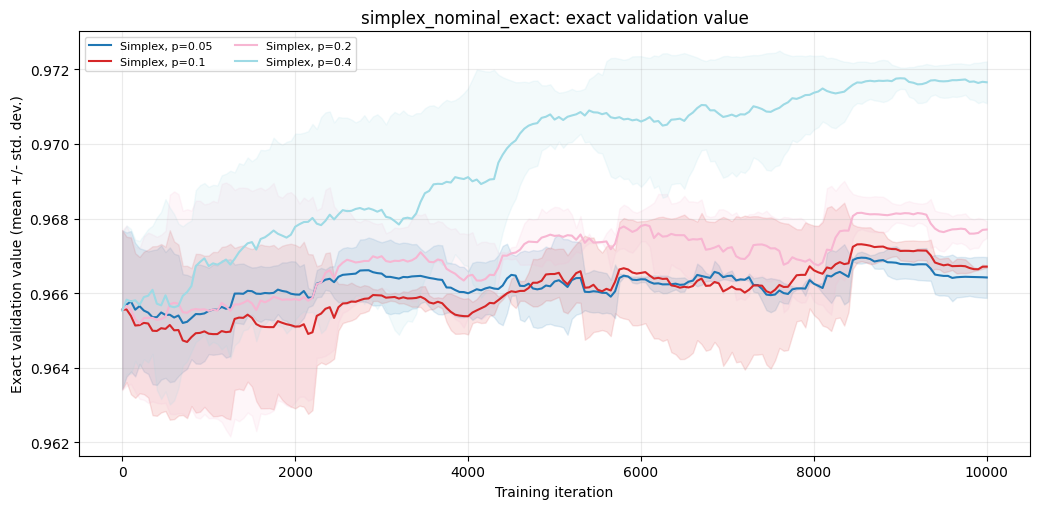

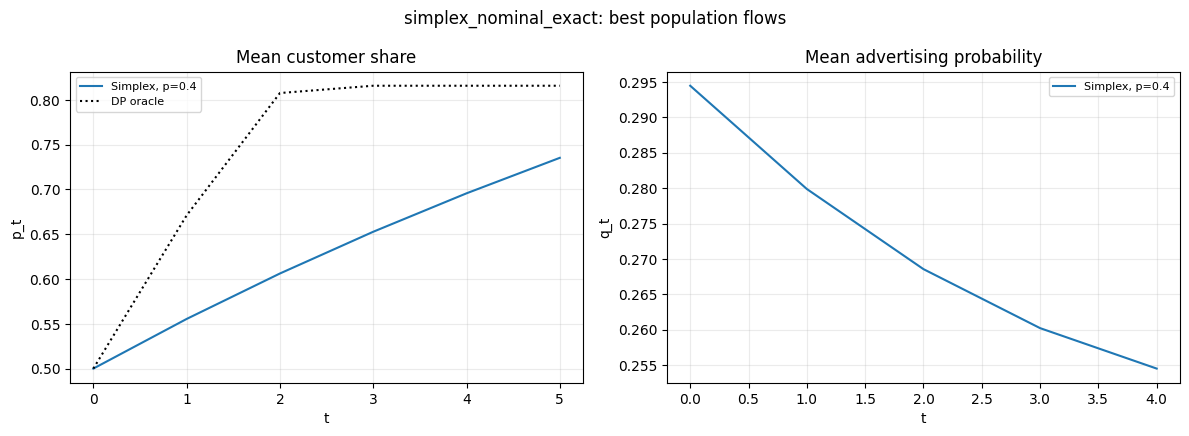

In [10]:
exact_nominal_budget_gradient_study = run_advertising_simplex_diagnostics(
    exact_nominal_budget,
    config,
    simplex_lambdas,
    advertising_run_plans,
    repetitions=diagnostic_repetitions,
    show_progress=True,
)
display(exact_nominal_budget_gradient_study.round(6))
show_advertising_results(exact_nominal_budget, advertising_calibration)


## Experiment 2: Exact Flow, Full Simplex Budget

Simplex uses `(B, n_aux) = (5425, 775)`, for `31000` simulated transitions per update when `T = 5`.

In [11]:
exact_full_budget = run_advertising_simplex_scenario(
    "simplex_full_budget_exact",
    config,
    simplex_lambdas,
    full_simplex_budgets,
    advertising_run_plans,
    validation_laws,
    advertising_oracle,
    flow_mode="exact",
    train_horizon=train_horizon,
    validation_horizon=validation_horizon,
    show_progress=True,
    early_stopping_patience=early_stopping_patience,
    max_runtime_seconds=max_runtime_seconds,
)


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,5425,775,5,exact,0,31000,1.0


simplex_full_budget_exact Simplex lambda=0.05 run=0:   3%|▎         | 340/10000 [02:52<1:21:44,  1.97it/s, grad=0.119, regret=0.0446, value=0.9642]


KeyboardInterrupt: 

In [ ]:
exact_full_budget_gradient_study = run_advertising_simplex_diagnostics(
    exact_full_budget,
    config,
    simplex_lambdas,
    advertising_run_plans,
    repetitions=diagnostic_repetitions,
    show_progress=True,
)
display(exact_full_budget_gradient_study.round(6))
show_advertising_results(exact_full_budget, advertising_calibration)


## Experiment 3: Estimated Flow, Full Simplex Budget

Training conditions on a particle-estimated population flow with `flow_particles = 200`. Validation remains deterministic and exact.

In [ ]:
estimated_full_budget = run_advertising_simplex_scenario(
    "simplex_full_budget_estimated_flow",
    config,
    simplex_lambdas,
    full_simplex_budgets,
    advertising_run_plans,
    validation_laws,
    advertising_oracle,
    flow_mode="particle",
    flow_particles=particle_flow_particles,
    train_horizon=train_horizon,
    validation_horizon=validation_horizon,
    show_progress=True,
    early_stopping_patience=early_stopping_patience,
    max_runtime_seconds=max_runtime_seconds,
)


In [ ]:
estimated_full_budget_gradient_study = run_advertising_simplex_diagnostics(
    estimated_full_budget,
    config,
    simplex_lambdas,
    advertising_run_plans,
    repetitions=diagnostic_repetitions,
    show_progress=True,
)
display(estimated_full_budget_gradient_study.round(6))
show_advertising_results(estimated_full_budget, advertising_calibration)


## Final Summary

The table below collects the fixed-simplex protocols. The gradient table stacks empirical gradient diagnostics for the initial policy and the best final simplex policy in each protocol.

In [ ]:
cross_protocol_summary = pd.concat(
    [
        scenario_summary_table(exact_nominal_budget, "simplex_nominal_exact"),
        scenario_summary_table(exact_full_budget, "simplex_full_budget_exact"),
        scenario_summary_table(estimated_full_budget, "simplex_full_budget_estimated_flow"),
    ],
    ignore_index=True,
)

gradient_protocol_summary = pd.concat(
    [
        exact_nominal_budget_gradient_study.assign(experiment="simplex_nominal_exact"),
        exact_full_budget_gradient_study.assign(experiment="simplex_full_budget_exact"),
        estimated_full_budget_gradient_study.assign(experiment="simplex_full_budget_estimated_flow"),
    ],
    ignore_index=True,
)

display(cross_protocol_summary.round(6))
display(gradient_protocol_summary.round(6))
